# PEPE Hourly Factor Research Regression

This notebook tests how PEPE hourly returns move with contemporaneous crypto market factors, BTC volatility/risk proxies, hourly ETF market proxies, and slow macro variables aligned to the Binance hourly timeline. It is an explanatory research regression, so some predictors are same-hour factors rather than tradeable signals. Use the trading forecast notebook for strictly lagged, backtest-oriented signals.


## Setup and hourly data configuration


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import ElasticNet, Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm

# Setup
project_root = next(
    path for path in [Path.cwd().resolve(), *Path.cwd().resolve().parents]
    if (path / "refresh_data.py").exists() and (path / "data").exists()
)
time_interval = "1H"
raw_data_dir = project_root / "data" / "raw" / "binance_daily"
data_path = raw_data_dir / f"binance_spot_{time_interval}_ohlcv_combined.csv"
fred_data_path = project_root / "data" / "raw" / "fred_macro" / "fred_macro_1D_combined.csv"
yfinance_data_path = project_root / "data" / "raw" / "yfinance_market" / f"yfinance_market_{time_interval}_ohlcv_combined.csv"
btc_funding_path = project_root / "data" / "raw" / "binance_funding" / f"BTCUSDT_funding_rate_{time_interval}.csv"
btc_dvol_path = project_root / "data" / "raw" / "deribit_dvol" / f"BTC_DVOL_{time_interval}.csv"

coin_order = ["PEPE", "BTC", "ETH", "SOL", "BNB", "XRP", "DOGE", "SHIB"]
target = "PEPE"
coin_colors = {
    "PEPE": "green",
    "BTC": "orange",
    "ETH": "grey",
    "SOL": "purple",
    "BNB": "gold",
    "XRP": "navy",
    "DOGE": "red",
    "SHIB": "brown",
}


## Load Binance hourly crypto data


In [2]:
# Load downloaded Binance spot OHLCV data
df = pd.read_csv(data_path, parse_dates=["timestamp"])
df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["coin"] = df["symbol"].str.replace("USDT", "", regex=False)

numeric_columns = ["open", "high", "low", "close", "volume"]
for column in numeric_columns:
    df[column] = pd.to_numeric(df[column], errors="coerce")

close_prices = df.pivot(index="timestamp", columns="coin", values="close").sort_index()
close_prices = close_prices[coin_order].replace([np.inf, -np.inf], np.nan)

open_prices = df.pivot(index="timestamp", columns="coin", values="open").sort_index()
high_prices = df.pivot(index="timestamp", columns="coin", values="high").sort_index()
low_prices = df.pivot(index="timestamp", columns="coin", values="low").sort_index()
volume_from = df.pivot(index="timestamp", columns="coin", values="volume").sort_index()

open_prices = open_prices[coin_order].replace([np.inf, -np.inf], np.nan)
high_prices = high_prices[coin_order].replace([np.inf, -np.inf], np.nan)
low_prices = low_prices[coin_order].replace([np.inf, -np.inf], np.nan)
volume_from = volume_from[coin_order].replace([np.inf, -np.inf], np.nan)


## Build hourly (log) returns and aligned external factors


In [3]:
# Build returns and hourly aligned factor inputs
raw_returns = close_prices.pct_change(fill_method=None)
raw_returns = raw_returns[coin_order].replace([np.inf, -np.inf], np.nan)
for coin in coin_order:
    first_valid_timestamp = close_prices[coin].first_valid_index()
    if first_valid_timestamp is not None:
        raw_returns.loc[first_valid_timestamp, coin] = 0.0

log_returns = np.log(close_prices / close_prices.shift(1))
log_returns = log_returns[coin_order].replace([np.inf, -np.inf], np.nan)
for coin in coin_order:
    first_valid_timestamp = close_prices[coin].first_valid_index()
    if first_valid_timestamp is not None:
        log_returns.loc[first_valid_timestamp, coin] = 0.0

fred_data = pd.read_csv(fred_data_path, parse_dates=["date"])
fred_data["date"] = pd.to_datetime(fred_data["date"], utc=True)
fred_data["value"] = pd.to_numeric(fred_data["value"], errors="coerce")
fred_features = fred_data.pivot(index="date", columns="factor", values="value").sort_index()
fred_features = fred_features.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

yfinance_data = pd.read_csv(yfinance_data_path, parse_dates=["date"])
yfinance_data["date"] = pd.to_datetime(yfinance_data["date"], utc=True).dt.floor("h")
yfinance_data["close"] = pd.to_numeric(yfinance_data["close"], errors="coerce")
yfinance_closes = yfinance_data.pivot(index="date", columns="factor", values="close").sort_index()
yfinance_closes = yfinance_closes.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)
yfinance_log_returns = np.log(yfinance_closes / yfinance_closes.shift(1)).replace([np.inf, -np.inf], np.nan)

btc_funding = pd.read_csv(btc_funding_path, parse_dates=["date"])
btc_funding["date"] = pd.to_datetime(btc_funding["date"], utc=True)
btc_funding["funding_rate_sum"] = pd.to_numeric(btc_funding["funding_rate_sum"], errors="coerce")
btc_funding = btc_funding.set_index("date").sort_index()
btc_funding = btc_funding.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

btc_dvol = pd.read_csv(btc_dvol_path)
dvol_time_column = "timestamp" if "timestamp" in btc_dvol.columns else "date"
btc_dvol[dvol_time_column] = pd.to_datetime(btc_dvol[dvol_time_column], utc=True)
btc_dvol["close"] = pd.to_numeric(btc_dvol["close"], errors="coerce")
btc_dvol = btc_dvol.set_index(dvol_time_column).sort_index()
btc_dvol = btc_dvol.reindex(close_prices.index).ffill().replace([np.inf, -np.inf], np.nan)

cumulative_returns = np.exp(log_returns.cumsum()) - 1
simple_cumulative_returns = (1 + raw_returns).cumprod() - 1

print("Simple cumulative return:")
print(simple_cumulative_returns.tail())
print()


Simple cumulative return:
coin                           PEPE       BTC       ETH       SOL       BNB  \
timestamp                                                                     
2026-07-29 04:00:00+00:00 -0.737799 -0.014325 -0.403479 -0.560232 -0.011009   
2026-07-29 05:00:00+00:00 -0.735885 -0.012800 -0.401282 -0.558855 -0.009148   
2026-07-29 06:00:00+00:00 -0.734928 -0.007125 -0.398890 -0.556460 -0.006557   
2026-07-29 07:00:00+00:00 -0.735885 -0.005193 -0.397472 -0.555383 -0.005391   
2026-07-29 08:00:00+00:00 -0.737799 -0.007982 -0.400374 -0.557538 -0.007757   

coin                            XRP      DOGE      SHIB  
timestamp                                                
2026-07-29 04:00:00+00:00  0.835258 -0.402692 -0.708386  
2026-07-29 05:00:00+00:00  0.844090 -0.402184 -0.705845  
2026-07-29 06:00:00+00:00  0.847317 -0.400660 -0.706480  
2026-07-29 07:00:00+00:00  0.851732 -0.399052 -0.705845  
2026-07-29 08:00:00+00:00  0.844939 -0.402692 -0.707751  



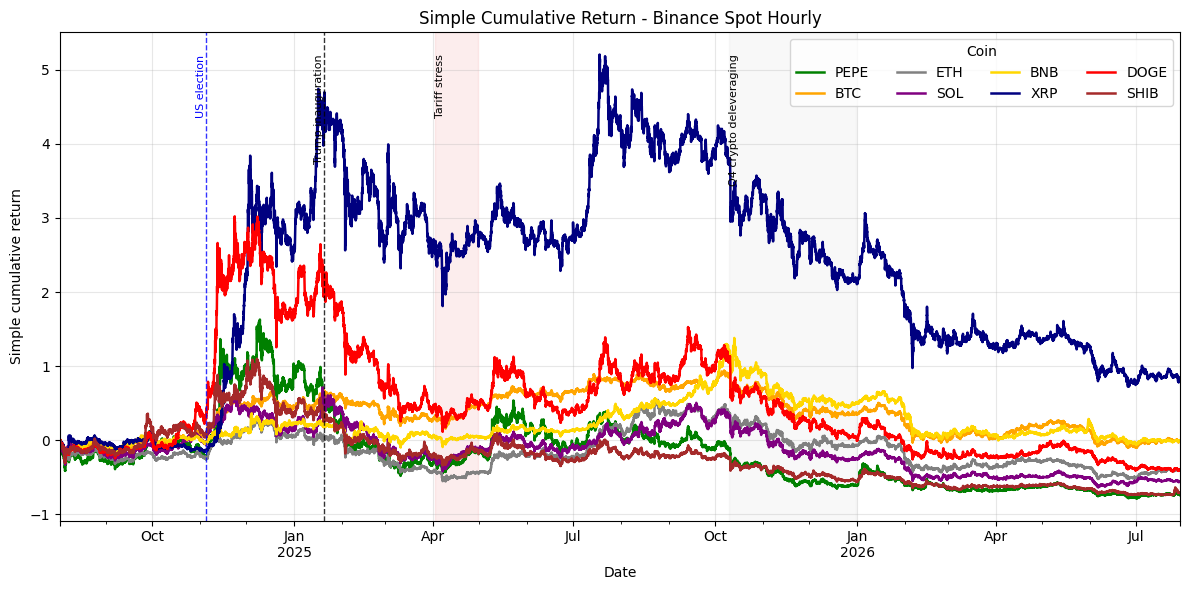

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))
simple_cumulative_returns.plot(
    ax=ax,
    linewidth=1.8,
    color=[coin_colors.get(coin) for coin in simple_cumulative_returns.columns],
)

chart_start = simple_cumulative_returns.index.min()
chart_end = simple_cumulative_returns.index.max()
event_y = simple_cumulative_returns.max().max()

event_spans = [
    {"label": "Tariff stress", "start": "2025-04-02", "end": "2025-04-30", "color": "lightcoral"},
    {"label": "Q4 crypto deleveraging", "start": "2025-10-10", "end": "2025-12-31", "color": "lightgrey"},
]

event_lines = [
    {"label": "US election", "date": "2024-11-05", "color": "blue"},
    {"label": "Trump inauguration", "date": "2025-01-20", "color": "black"},
]

for event in event_spans:
    start = pd.Timestamp(event["start"], tz="UTC")
    end = pd.Timestamp(event["end"], tz="UTC")
    if end < chart_start or start > chart_end:
        continue
    visible_start = max(start, chart_start)
    visible_end = min(end, chart_end)
    ax.axvspan(visible_start, visible_end, color=event["color"], alpha=0.14)
    ax.text(visible_start, event_y, event["label"], rotation=90, va="top", ha="left", fontsize=8, color="black")

for event in event_lines:
    date = pd.Timestamp(event["date"], tz="UTC")
    if date < chart_start or date > chart_end:
        continue
    ax.axvline(date, color=event["color"], linewidth=1.0, linestyle="--", alpha=0.8)
    ax.text(date, event_y, event["label"], rotation=90, va="top", ha="right", fontsize=8, color=event["color"])

plt.title("Simple Cumulative Return - Binance Spot Hourly")
plt.xlabel("Date")
plt.ylabel("Simple cumulative return")
plt.grid(True, alpha=0.3)
plt.legend(title="Coin", ncols=4)
plt.tight_layout()
plt.show()


## Build explanatory feature matrix


In [5]:
# Build same-hour feature matrix for explanatory fit testing
# - target PEPE is the current hourly log return
# - broad market returns are same-hour features
# - PEPE/BTC technical factors are same-hour descriptive features
# - this matrix explains co-movement and market state, not tradable forecasts
features = pd.DataFrame(index=log_returns.index)

# Crypto features
features["BTC"] = log_returns["BTC"]
features["ETH"] = log_returns["ETH"]
features["SOL"] = log_returns["SOL"]
features["BNB"] = log_returns["BNB"]
features["XRP"] = log_returns["XRP"]
features["DOGE"] = log_returns["DOGE"]
features["SHIB"] = log_returns["SHIB"]

# PEPE same-hour descriptive features
features["PEPE_momentum_7h"] = log_returns["PEPE"].rolling(7).sum()
features["PEPE_momentum_14h"] = log_returns["PEPE"].rolling(14).sum()
features["PEPE_volatility_7h"] = log_returns["PEPE"].rolling(7).std()
features["PEPE_volatility_14h"] = log_returns["PEPE"].rolling(14).std()
features["PEPE_volume_change"] = np.log(volume_from["PEPE"] / volume_from["PEPE"].shift(1))
features["PEPE_range"] = (high_prices["PEPE"] - low_prices["PEPE"]) / close_prices["PEPE"]

# BTC same-hour descriptive features
features["BTC_volatility_14h"] = log_returns["BTC"].rolling(14).std()
features["BTC_range"] = (high_prices["BTC"] - low_prices["BTC"]) / close_prices["BTC"]
features["BTC_funding_rate_sum"] = btc_funding["funding_rate_sum"]

if btc_dvol["close"].notna().sum() >= 500:
    features["BTC_DVOL_change"] = btc_dvol["close"].diff()
else:
    print("Skipping BTC_DVOL_change: insufficient hourly overlap.")

# Slow macro features, forward-filled from FRED
features["M2_30d_change"] = np.log(fred_features["m2_money_supply"] / fred_features["m2_money_supply"].shift(24 * 30))
features["SOFR_change"] = fred_features["sofr"].diff()
features["DFF_change"] = fred_features["effective_fed_funds_rate"].diff()

# Hourly market proxy ETF features
features["QQQ"] = yfinance_log_returns["nasdaq_100_etf"]
features["SPY"] = yfinance_log_returns["sp500_etf"]
features["IEF"] = yfinance_log_returns["treasury_7_10y_etf"]
features["TLT"] = yfinance_log_returns["treasury_20y_etf"]
features["UUP"] = yfinance_log_returns["us_dollar_index_proxy"]
features["HYG"] = yfinance_log_returns["high_yield_credit_proxy"]
features["VXX"] = yfinance_log_returns["vix_futures_proxy"]

# PEPE same-hour technical indicators
features["PEPE_SMA12h"] = log_returns["PEPE"].rolling(12).mean()
features["PEPE_SMA26h"] = log_returns["PEPE"].rolling(26).mean()

pepe_close_change = close_prices["PEPE"].diff()
pepe_gain = pepe_close_change.clip(lower=0)
pepe_loss = -pepe_close_change.clip(upper=0)
pepe_avg_gain_14h = pepe_gain.rolling(14).mean()
pepe_avg_loss_14h = pepe_loss.rolling(14).mean()
features["PEPE_RSI_14h"] = 100 - (100 / (1 + pepe_avg_gain_14h / pepe_avg_loss_14h))

pepe_bb_middle_20h = close_prices["PEPE"].rolling(20).mean()
pepe_bb_std_20h = close_prices["PEPE"].rolling(20).std()
pepe_bb_upper_20h = pepe_bb_middle_20h + 2 * pepe_bb_std_20h
pepe_bb_lower_20h = pepe_bb_middle_20h - 2 * pepe_bb_std_20h
features["PEPE_BB_percent_b_20h"] = (
    (close_prices["PEPE"] - pepe_bb_lower_20h) / (pepe_bb_upper_20h - pepe_bb_lower_20h)
)

model_data = pd.concat([log_returns[target].rename(target), features], axis=1).dropna()

print("Model data:")
with pd.option_context(
    "display.max_columns", None,
    "display.width", None,
    "display.expand_frame_repr", False,
):
    print(model_data.head(10))

print()
print("Dependent Variable is current-hour PEPE log return.")
print("Predictors are same-hour explanatory features, including crypto returns, market proxies, macro context, funding, DVOL, and PEPE/BTC technical state.")
print("This research matrix explains co-movement and market state. It is not a tradable forecast matrix.")

print("Predictors use Binance spot hourly OHLCV plus hourly yfinance ETF proxies.")
print("FRED macro series are lower frequency and forward-filled onto hourly timestamps.")


Model data:
                               PEPE       BTC       ETH       SOL       BNB       XRP      DOGE      SHIB  PEPE_momentum_7h  PEPE_momentum_14h  PEPE_volatility_7h  PEPE_volatility_14h  PEPE_volume_change  PEPE_range  BTC_volatility_14h  BTC_range  BTC_funding_rate_sum  BTC_DVOL_change  M2_30d_change  SOFR_change  DFF_change  QQQ  SPY  IEF  TLT  UUP  HYG  VXX  PEPE_SMA12h   PEPE_SMA26h  PEPE_RSI_14h  PEPE_BB_percent_b_20h
timestamp                                                                                                                                                                                                                                                                                                                                                                                                                               
2024-10-01 00:00:00+00:00  0.014238  0.003222  0.006355  0.010957  0.007900  0.014291  0.013394  0.036876         -0.024210          -0.01

In [11]:
## Feature correlation diagnostics
print(features.isna().sum().sort_values(ascending=False).to_string())
print()

feature_count = features.shape[1]
print(f"Number of model features: {feature_count}")

M2_30d_change            1440
PEPE_SMA26h                25
PEPE_BB_percent_b_20h      19
IEF                        14
SPY                        14
TLT                        14
UUP                        14
QQQ                        14
PEPE_RSI_14h               14
HYG                        14
VXX                        14
PEPE_volatility_14h        13
BTC_volatility_14h         13
PEPE_momentum_14h          13
PEPE_SMA12h                11
PEPE_volatility_7h          6
PEPE_momentum_7h            6
SOFR_change                 1
PEPE_volume_change          1
BTC_DVOL_change             1
DFF_change                  1
BTC_range                   0
SHIB                        0
BTC                         0
PEPE_range                  0
ETH                         0
SOL                         0
BNB                         0
XRP                         0
DOGE                        0
BTC_funding_rate_sum        0

Number of model features: 31


## Feature correlation diagnostics


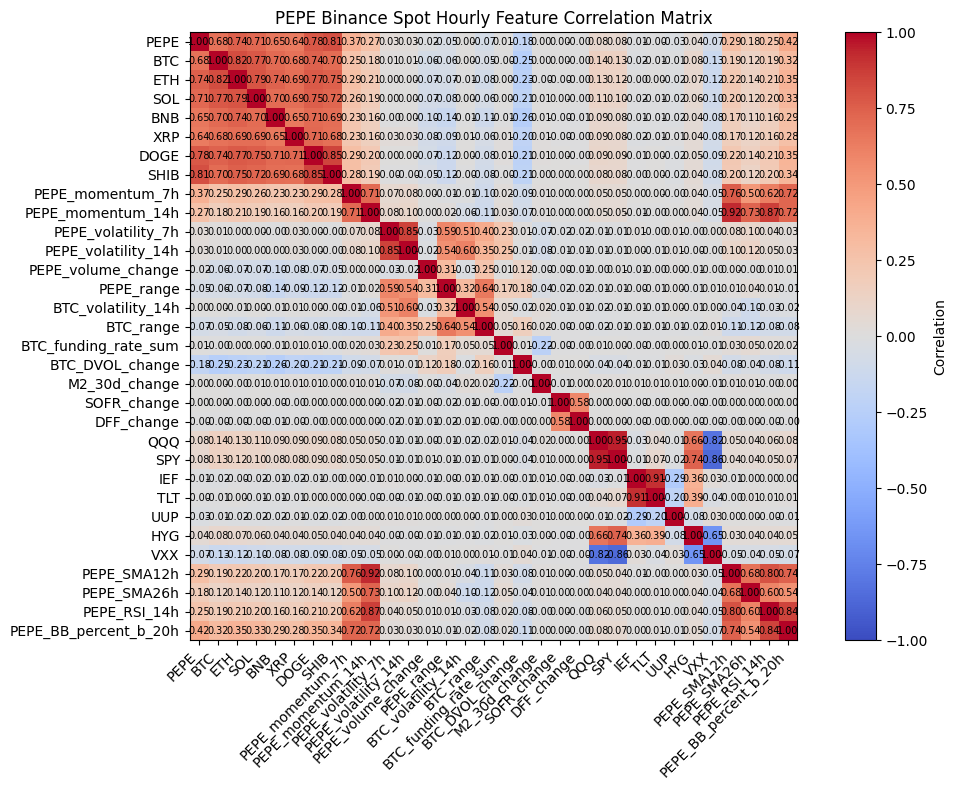

In [7]:
# Correlation matrix
correlation_matrix = model_data.corr()

plt.figure(figsize=(11, 8))
plt.imshow(correlation_matrix, cmap="coolwarm", vmin=-1, vmax=1)
plt.colorbar(label="Correlation")
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45, ha="right")
plt.yticks(range(len(correlation_matrix.index)), correlation_matrix.index)
plt.title("PEPE Binance Spot Hourly Feature Correlation Matrix")

for row_index, row_name in enumerate(correlation_matrix.index):
    for column_index, column_name in enumerate(correlation_matrix.columns):
        value = correlation_matrix.iloc[row_index, column_index]
        plt.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=7)

plt.tight_layout()
plt.show()

## Fit explanatory regression models


In [8]:
# Linear, Ridge, and ElasticNet regression
feature_columns = list(features.columns)
split_idx = int(len(model_data) * 0.8)

train_data = model_data.iloc[:split_idx]
test_data = model_data.iloc[split_idx:]

X_train = sm.add_constant(train_data[feature_columns], has_constant="add")
y_train = train_data[target]
X_test = sm.add_constant(test_data[feature_columns], has_constant="add")
y_test = test_data[target]

model = sm.OLS(y_train, X_train).fit()
y_pred = model.predict(X_test)

train_r2 = model.rsquared
adjusted_train_r2 = 1 - (1 - train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
test_r2 = r2_score(y_test, y_pred)
adjusted_test_r2 = 1 - (1 - test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
pred_corr = np.corrcoef(y_test, y_pred)[0, 1]

cv_r2s = []
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(train_data):
    cv_X_train = sm.add_constant(train_data.iloc[train_idx][feature_columns], has_constant="add")
    cv_y_train = train_data.iloc[train_idx][target]
    cv_X_val = sm.add_constant(train_data.iloc[val_idx][feature_columns], has_constant="add")
    cv_y_val = train_data.iloc[val_idx][target]
    cv_model = sm.OLS(cv_y_train, cv_X_train).fit()
    cv_pred = cv_model.predict(cv_X_val)
    cv_r2s.append(r2_score(cv_y_val, cv_pred))

coefficients = model.params.rename("coefficient")


print()
print(model.summary())

ridge_X_train = train_data[feature_columns]
ridge_X_test = test_data[feature_columns]
ridge_alphas = [0.01, 0.1, 1, 10, 100, 300, 1000, 3000, 10000]

ridge_cv_results = []

for alpha in ridge_alphas:
    alpha_cv_r2s = []
    for train_idx, val_idx in tscv.split(train_data):
        cv_X_train = train_data.iloc[train_idx][feature_columns]
        cv_y_train = train_data.iloc[train_idx][target]
        cv_X_val = train_data.iloc[val_idx][feature_columns]
        cv_y_val = train_data.iloc[val_idx][target]
        cv_ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=alpha))
        cv_ridge_model.fit(cv_X_train, cv_y_train)
        alpha_cv_r2s.append(r2_score(cv_y_val, cv_ridge_model.predict(cv_X_val)))
    ridge_cv_results.append({"alpha": alpha, "cv_r2_mean": np.mean(alpha_cv_r2s)})

ridge_cv_results = pd.DataFrame(ridge_cv_results)
best_ridge_alpha = ridge_cv_results.loc[ridge_cv_results["cv_r2_mean"].idxmax(), "alpha"]
ridge_model = make_pipeline(StandardScaler(), Ridge(alpha=best_ridge_alpha))
ridge_model.fit(ridge_X_train, y_train)
ridge_y_pred = ridge_model.predict(ridge_X_test)

ridge_train_r2 = ridge_model.score(ridge_X_train, y_train)
ridge_adjusted_train_r2 = 1 - (1 - ridge_train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
ridge_test_r2 = r2_score(y_test, ridge_y_pred)
ridge_adjusted_test_r2 = 1 - (1 - ridge_test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_y_pred))
ridge_pred_corr = np.corrcoef(y_test, ridge_y_pred)[0, 1]

ridge_coefficients = pd.Series(
    ridge_model.named_steps["ridge"].coef_,
    index=feature_columns,
    name="coefficient",
)

elastic_net_alphas = [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0]
elastic_net_l1_ratios = [0.1, 0.5, 0.9]
elastic_net_cv_results = []

for alpha in elastic_net_alphas:
    for l1_ratio in elastic_net_l1_ratios:
        alpha_cv_r2s = []
        for train_idx, val_idx in tscv.split(train_data):
            cv_X_train = train_data.iloc[train_idx][feature_columns]
            cv_y_train = train_data.iloc[train_idx][target]
            cv_X_val = train_data.iloc[val_idx][feature_columns]
            cv_y_val = train_data.iloc[val_idx][target]
            cv_elastic_net_model = make_pipeline(
                StandardScaler(),
                ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=100000),
            )
            cv_elastic_net_model.fit(cv_X_train, cv_y_train)
            alpha_cv_r2s.append(r2_score(cv_y_val, cv_elastic_net_model.predict(cv_X_val)))
        elastic_net_cv_results.append(
            {
                "alpha": alpha,
                "l1_ratio": l1_ratio,
                "cv_r2_mean": np.mean(alpha_cv_r2s),
            }
        )

elastic_net_cv_results = pd.DataFrame(elastic_net_cv_results)
best_elastic_net_params = elastic_net_cv_results.loc[elastic_net_cv_results["cv_r2_mean"].idxmax()]
elastic_net_model = make_pipeline(
    StandardScaler(),
    ElasticNet(
        alpha=best_elastic_net_params["alpha"],
        l1_ratio=best_elastic_net_params["l1_ratio"],
        max_iter=100000,
    ),
)
elastic_net_model.fit(ridge_X_train, y_train)
elastic_net_y_pred = elastic_net_model.predict(ridge_X_test)

elastic_net_train_r2 = elastic_net_model.score(ridge_X_train, y_train)
elastic_net_adjusted_train_r2 = 1 - (1 - elastic_net_train_r2) * (len(y_train) - 1) / (len(y_train) - len(feature_columns) - 1)
elastic_net_test_r2 = r2_score(y_test, elastic_net_y_pred)
elastic_net_adjusted_test_r2 = 1 - (1 - elastic_net_test_r2) * (len(y_test) - 1) / (len(y_test) - len(feature_columns) - 1)
elastic_net_rmse = np.sqrt(mean_squared_error(y_test, elastic_net_y_pred))
elastic_net_pred_corr = np.corrcoef(y_test, elastic_net_y_pred)[0, 1]
elastic_net_nonzero_coefficients = np.count_nonzero(elastic_net_model.named_steps["elasticnet"].coef_)

elastic_net_coefficients = pd.Series(
    elastic_net_model.named_steps["elasticnet"].coef_,
    index=feature_columns,
    name="coefficient",
)

model_comparison = pd.DataFrame(
    [
        {
            "model": "OLS",
            "alpha": np.nan,
            "l1_ratio": np.nan,
            "nonzero_coef": len(feature_columns),
            "train_r2": train_r2,
            "adj_train_r2": adjusted_train_r2,
            "test_r2": test_r2,
            "adj_test_r2": adjusted_test_r2,
            "rmse": rmse,
            "pred_corr": pred_corr,
            "cv_r2_mean": np.mean(cv_r2s),
        },
        {
            "model": "Ridge",
            "alpha": best_ridge_alpha,
            "l1_ratio": np.nan,
            "nonzero_coef": np.count_nonzero(ridge_model.named_steps["ridge"].coef_),
            "train_r2": ridge_train_r2,
            "adj_train_r2": ridge_adjusted_train_r2,
            "test_r2": ridge_test_r2,
            "adj_test_r2": ridge_adjusted_test_r2,
            "rmse": ridge_rmse,
            "pred_corr": ridge_pred_corr,
            "cv_r2_mean": ridge_cv_results["cv_r2_mean"].max(),
        },
        {
            "model": "ElasticNet",
            "alpha": best_elastic_net_params["alpha"],
            "l1_ratio": best_elastic_net_params["l1_ratio"],
            "nonzero_coef": elastic_net_nonzero_coefficients,
            "train_r2": elastic_net_train_r2,
            "adj_train_r2": elastic_net_adjusted_train_r2,
            "test_r2": elastic_net_test_r2,
            "adj_test_r2": elastic_net_adjusted_test_r2,
            "rmse": elastic_net_rmse,
            "pred_corr": elastic_net_pred_corr,
            "cv_r2_mean": elastic_net_cv_results["cv_r2_mean"].max(),
        },
    ]
)




                            OLS Regression Results                            
Dep. Variable:                   PEPE   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     1179.
Date:                Wed, 29 Jul 2026   Prob (F-statistic):               0.00
Time:                        16:27:57   Log-Likelihood:                 46107.
No. Observations:               12794   AIC:                        -9.215e+04
Df Residuals:                   12762   BIC:                        -9.191e+04
Df Model:                          31                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
const                     0.0

### Model comparison and ElasticNet coefficients

Elastic Net coefficients are shown directly below the model comparison so the selected features are easy to inspect.


In [9]:
print("Model comparison")
print(model_comparison.to_string(index=False, float_format=lambda value: f"{value:.6f}"))

elastic_net_selected_coefficients = (
    elastic_net_coefficients[elastic_net_coefficients.ne(0)]
    .rename("coefficient")
    .reset_index()
    .rename(columns={"index": "feature"})
)
elastic_net_selected_coefficients["abs_coefficient"] = elastic_net_selected_coefficients["coefficient"].abs()
elastic_net_selected_coefficients = elastic_net_selected_coefficients.sort_values(
    "abs_coefficient",
    ascending=False,
).reset_index(drop=True)

print()
print("ElasticNet selected coefficients")
print(elastic_net_selected_coefficients.to_string(index=False, float_format=lambda value: f"{value:.6g}"))


Model comparison
     model       alpha  l1_ratio  nonzero_coef  train_r2  adj_train_r2  test_r2  adj_test_r2     rmse  pred_corr  cv_r2_mean
       OLS         NaN       NaN            31  0.741122      0.740493 0.695073     0.692089 0.004526   0.838587    0.743213
     Ridge 1000.000000       NaN            31  0.737719      0.737082 0.709846     0.707006 0.004415   0.844807    0.751488
ElasticNet    0.010000  0.100000             6  0.721303      0.720626 0.697541     0.694581 0.004508   0.835412    0.771168

ElasticNet selected coefficients
              feature  coefficient  abs_coefficient
                 SHIB   0.00529895       0.00529895
                  ETH   0.00213136       0.00213136
                 DOGE   0.00182448       0.00182448
                  SOL  0.000972858      0.000972858
     PEPE_momentum_7h  0.000576316      0.000576316
PEPE_BB_percent_b_20h  0.000491771      0.000491771


## Model comparison and diagnostics


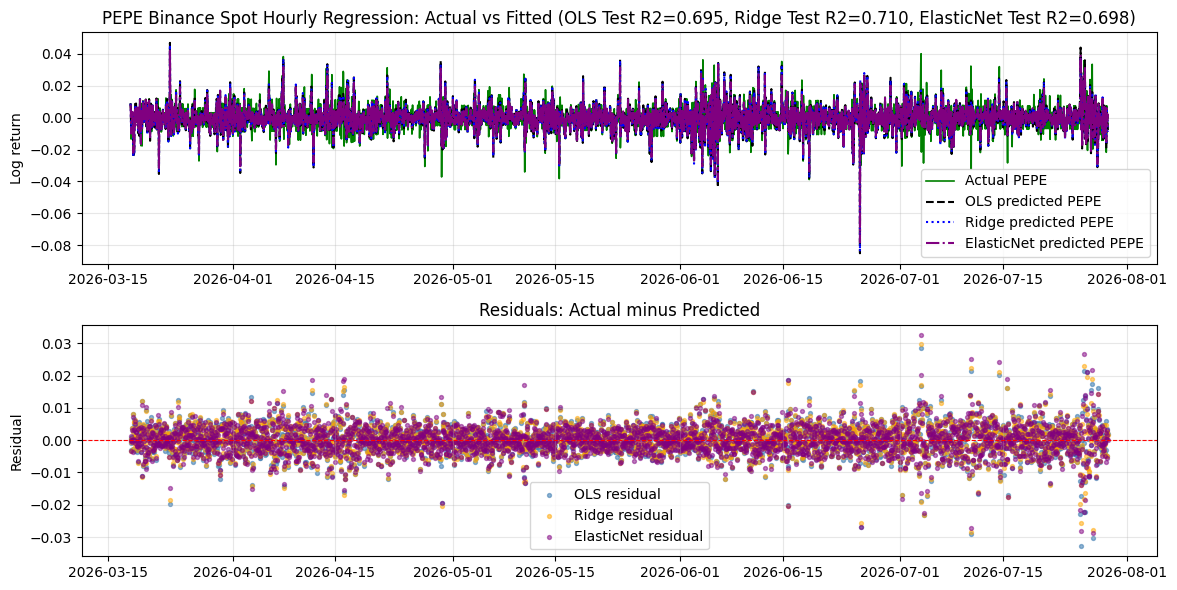

In [10]:
# Regression chart
fig, axes = plt.subplots(2, 1, figsize=(12, 6))

axes[0].plot(test_data.index, y_test, label="Actual PEPE", color="green", linewidth=1.2)
axes[0].plot(test_data.index, y_pred, label="OLS predicted PEPE", color="black", linestyle="--")
axes[0].plot(test_data.index, ridge_y_pred, label="Ridge predicted PEPE", color="blue", linestyle=":")
axes[0].plot(test_data.index, elastic_net_y_pred, label="ElasticNet predicted PEPE", color="purple", linestyle="-.")
axes[0].set_title(
    f"PEPE Binance Spot Hourly Regression: Actual vs Fitted "
    f"(OLS Test R2={test_r2:.3f}, Ridge Test R2={ridge_test_r2:.3f}, "
    f"ElasticNet Test R2={elastic_net_test_r2:.3f})"
)
axes[0].set_ylabel("Log return")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
ridge_residuals = y_test - ridge_y_pred
elastic_net_residuals = y_test - elastic_net_y_pred
axes[1].scatter(test_data.index, residuals, s=8, color="steelblue", alpha=0.6, label="OLS residual")
axes[1].scatter(test_data.index, ridge_residuals, s=8, color="orange", alpha=0.5, label="Ridge residual")
axes[1].scatter(test_data.index, elastic_net_residuals, s=8, color="purple", alpha=0.5, label="ElasticNet residual")
axes[1].axhline(0, color="red", linewidth=0.8, linestyle="--")
axes[1].set_title("Residuals: Actual minus Predicted")
axes[1].set_ylabel("Residual")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Notebook-only outputs

This notebook displays tables, summaries, and charts inline. It does not save research CSV, TXT, or PNG output files.